# FDSI benchmark: per-condition hyperparameter optimisation — lr_v/lr_b mechanism (kl_to_cal + penalty)

Same per-condition Optuna CMA-ES search and application pipeline as `fdsi_02`–`fdsi_05`, but on the reordered whitening/separation update: the natural-gradient direction is normalized to unit scale (EMA of its own norm) *before* being scaled by the real learning rate (`lr_v`/`lr_b`) and the signed error, instead of being scaled by the error and *then* clipped to a fixed size on ~100% of batches (the behaviour measured in `fdsi_05`). `max_rel_delta_{v,b}` is superseded — the trust-region clip is now a rare safety net sized as `safety_clip_multiplier_{v,b} × lr_{v,b}`, not independently tuned.

This experiment: `wh_mode='kl_to_cal'`, `silence_penalty=True`.

Calibration is loaded from the shared cache produced by `fdsi_01_apply_best_config` (§2) rather than recomputed — CBSS calibration uses the identical `CBSS_CFG`/`ROA_CAL_TH` across every `fdsi_0X` notebook, so recomputing it here would just repeat work already cached on disk.

**Pipeline**
1. Load CBSS calibration from the shared cache (no recomputation)
2. **Hyperparameter optimisation** — per condition, `sub-01` at 30 dB (CMA-ES, 50 trials, searching `lr_v`/`lr_b`)
3. Application — per-condition best config applied to all 100 recordings (fixed & adapted)
4. Clipping diagnostics — confirm the safety clip is now rare, not routine


In [ ]:
import sys
sys.path.insert(0, '../..')

import json
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from pathlib import Path
try:
    from tqdm.notebook import tqdm
except ImportError:
    from tqdm import tqdm

from adapt_decomp.adaptation import AdaptDecomp
from adapt_decomp.calibration import calibrate_from_indices, select_units_supervised
from adapt_decomp.cbss import CBSS, CBSSConfig, CBSSResult
from adapt_decomp.config import Config
from adapt_decomp.optimize import optimize_adapt_decomp, DEFAULT_PARAM_SPACE
from adapt_decomp.utils import rate_of_agreement, rate_of_agreement_paired

%load_ext autoreload
%autoreload 2

sns.set_theme(style='whitegrid', font_scale=1.1)


In [ ]:
# ── Run control ───────────────────────────────────────────────────────────────
# No RUN_CAL flag: calibration is always loaded from CALIBRATION_DIR (shared cache
# produced by fdsi_01_apply_best_config), never recomputed here -- see §2.
RUN_OPTIMISATION = False    # False → reload saved per-condition best configs from disk
RUN_DECOMP       = True    # False → reload cached fixed/adapted spikes from disk

FDSI_ROOT       = Path('C:/Users/Irene/Documents/work_local/muniverse/outputs/fdsi_benchmark')
CALIBRATION_DIR = Path('..', '..', 'data', 'muniverse_simulations', 'fdsi_01_max_rel_delta_kl_to_cal_no_coupling_sv_no_penalty_appliedcfg_fixed_allrec')       # shared cache (see §2)
RESULTS_DIR     = Path('..', '..', 'data', 'muniverse_simulations', 'fdsi_09_natural_gradient_kl_to_cal_no_coupling_sv_penalty_rel_error_cmaes_percond_iterb5')
OPT_DIR         = RESULTS_DIR / 'optimisation'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
OPT_DIR.mkdir(parents=True, exist_ok=True)

# ── Dataset constants ───────────────────────────────────────────────────
FS       = 2048
CAL_END  = int(5.0 * FS)   # first 5 s — stationary calibration window
ISO_DUR  = int(5.0 * FS)   # 5-s bookend for triangular phase analysis

SUBJECTS   = [f'sub-{i:02d}' for i in range(1, 6)]
CONDITIONS = ['triangular-ramp40s', 'triangular-ramp20s',
              'triangular-ramp10s', 'triangular-ramp5s', 'staircase']
TRIANGULAR = [c for c in CONDITIONS if 'triangular' in c]
SNR_LEVELS = [30, 25, 20, 15]
ROA_CAL_TH = 0.9

# ── CBSS calibration config ───────────────────────────────────────────────
# Must match the config that produced CALIBRATION_DIR's cache exactly (fs, ext_fact,
# sil_th, random_seed, ica_iter, search_iter) -- kept here only for parity/reference
# and because helper functions below expect CBSS_CFG.ext_fact.
CBSS_CFG = CBSSConfig(
    fs          = FS,
    ext_fact    = 10,
    sil_th      = 0.9,
    random_seed = 42,
    ica_iter    = 300,
    search_iter = 300,
    save_emg    = True,
)

# ── Hyperparameter optimisation settings ─────────────────────────────────────────
OPTIM_SUB    = 'sub-01'   # reference subject for optimisation
OPTIM_SNR    = 30          # reference SNR (dB) for optimisation
N_OPT_TRIALS = 50          # CMA-ES trials per condition

OPT_BASE_CONFIG = {
    'ext_fact':       CBSS_CFG.ext_fact,
    'adapt_wh':       True,
    'adapt_sv':       True,
    'adapt_sd':       True,
    'wh_mode':        'kl_to_cal',
    'contrast_scope': 'spike_based',
    'wh_b_coupling':  False,
    'max_iter_b':     5,
    'log_loss':       True,
    'device':         'cpu',
    'trace_check':    True,
    'optim_loss':     'single_obj',
    'silence_penalty': True,
}
OPT_PARAM_SPACE = DEFAULT_PARAM_SPACE   # lr_v, lr_b (centroid_momentum currently excluded)

def _to_json_safe(v):
    if isinstance(v, torch.Tensor): return v.item()
    if hasattr(v, 'item'):          return v.item()
    return v

print(f'FDSI root  : {FDSI_ROOT}')
print(f'Calibration: {CALIBRATION_DIR}  (shared cache, not recomputed)')
print(f'Results    : {RESULTS_DIR}')
print(f'Opt dir    : {OPT_DIR}')
print(f'Cal window : {CAL_END/FS:.0f} s  |  ISO bookend: {ISO_DUR/FS:.0f} s')
print(f'Opt ref    : {OPTIM_SUB}, {OPTIM_SNR} dB  |  {N_OPT_TRIALS} trials/condition')
print(f'Recordings : {len(SUBJECTS)} subs × {len(CONDITIONS)} conds × {len(SNR_LEVELS)} SNR = '
      f'{len(SUBJECTS)*len(CONDITIONS)*len(SNR_LEVELS)}')


## 1. Helper functions

In [3]:
def make_adapt_config(ext_fact: int, *, adapt: bool, log_loss: bool = True) -> Config:
    """Build an AdaptDecomp Config with default hyperparameters (no muniverse-tuned values)."""
    cfg = Config()
    cfg.ext_fact       = ext_fact
    cfg.log_loss       = log_loss
    cfg.device         = 'cpu'
    cfg.contrast_scope = 'spike_based'
    cfg.wh_mode        = 'kl_to_identity'
    cfg.batch_ms       = 100
    if not adapt:
        cfg.adapt_wh = False
        cfg.adapt_sv = False
        cfg.adapt_sd = False
    return cfg


def load_raw_recording(root, sub, cond, snr):
    """Load raw noisy EMG and ground-truth metadata for one FDSI recording."""
    root     = Path(root)
    emg_full = np.load(
        root / 'data' / sub / 'noisy' / f'{sub}_FDSI_{cond}_snr{snr}dB_emg.npz'
    )['emg']
    clean_dir  = root / 'data' / sub / 'clean'
    spikes_obj = np.load(clean_dir / f'{sub}_FDSI_{cond}_spikes.npz',
                         allow_pickle=True)['spikes']
    angle  = np.load(clean_dir / f'{sub}_FDSI_{cond}_angle.npz')['angle']
    effort = np.load(clean_dir / f'{sub}_FDSI_{cond}_effort.npz')['effort']
    return {'emg_full': emg_full, 'spikes_obj': spikes_obj, 'angle': angle, 'effort': effort}


def build_gt_cal_binary(spikes_obj, n_gt, n_cal):
    """Binary GT matrix for the calibration window.  Shape: (n_cal, n_gt)."""
    gt_bin = np.zeros((n_cal, n_gt), dtype=np.float32)
    for gt_idx in range(n_gt):
        idx = np.asarray(spikes_obj[gt_idx]).astype(int)
        idx = idx[(idx >= 0) & (idx < n_cal)]
        gt_bin[idx, gt_idx] = 1.0
    return gt_bin


def build_gt_full_binary_paired(spikes_obj, gt_matched_indices, n_full):
    """Binary GT matrix for the FULL recording (calibration + adaptation), ordered by CBSS unit.

    gt_matched_indices[i] → GT unit index for CBSS unit i.
    Shape: (n_full, n_kept).
    """
    n_kept = len(gt_matched_indices)
    gt_bin = np.zeros((n_full, n_kept), dtype=np.float32)
    for i, gt_idx in enumerate(gt_matched_indices):
        idx = np.asarray(spikes_obj[gt_idx]).astype(int)
        idx = idx[(idx >= 0) & (idx < n_full)]
        gt_bin[idx, i] = 1.0
    return gt_bin


def save_cbss_result(result, path):
    """Save a CBSSResult (arrays only) to a compressed npz file."""
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    data = {k: v for k, v in result.to_dict().items()
            if v is not None and not isinstance(v, dict)}
    np.savez_compressed(path, **data)


def load_cbss_result(path):
    """Reconstruct a CBSSResult from a file saved by save_cbss_result."""
    _c = np.load(path, allow_pickle=False)
    return CBSSResult(
        sources        = _c['sources'],
        spikes         = _c['spikes'],
        spikes_dict    = {},
        sil            = _c['sil'],
        cov            = _c['cov'],
        sep_vectors    = _c['sep_vectors'],
        whitening      = _c['whitening'],
        extension_mean = _c['extension_mean'],
        spikes_centr   = _c['spikes_centr'],
        base_centr     = _c['base_centr'],
        emg            = _c.get('emg'),
        gt_matched_indices = _c.get('gt_matched_indices'),
        roa = _c.get('roa'),
    )


In [4]:
def get_triangular_phases(n_full):
    """Fixed 5-s phase boundaries for triangular contractions.

    First isometric folds the calibration window into the initial stationary phase.
    Returns slices into a FULL-recording array (length n_full).

      [0 ─── CAL_END ─── CAL_END+ISO_DUR ─────── n_full-ISO_DUR ─── n_full]
       |<── calibration ──>|<── first iso ──>|<── ramp ──>|<── last iso ──>|
    """
    first_iso = slice(0,                   CAL_END + ISO_DUR)
    ramp      = slice(CAL_END + ISO_DUR,   n_full  - ISO_DUR)
    last_iso  = slice(n_full  - ISO_DUR,   n_full)
    return {'first_iso': first_iso, 'ramp': ramp, 'last_iso': last_iso}


def compute_roa_subset(gt_full_bin, pred_full_spikes, s):
    """RoA for a temporal subset; s is a slice into the full-recording arrays.

    Returns per-unit RoA array; NaN if the subset is empty.
    """
    sub_gt   = gt_full_bin[s]
    sub_pred = pred_full_spikes[s]
    if sub_gt.shape[0] == 0:
        return np.full(gt_full_bin.shape[1], np.nan)
    roa, _, _ = rate_of_agreement_paired(sub_gt, sub_pred, fs=FS, tol_spike_ms=2)
    return roa


## 2. CBSS calibration — loaded from shared cache

CBSS calibration uses the identical `CBSS_CFG`/`ROA_CAL_TH` across every `fdsi_0X` notebook, so recomputing it here would just repeat work `fdsi_01_apply_best_config` already did for all 100 recordings. This notebook loads that existing cache from `CALIBRATION_DIR` instead of recomputing it.

(This loader pattern can be back-ported to `fdsi_02`–`fdsi_05`, which currently each recompute the same calibration independently, to eliminate that redundancy — not done as part of this change.)


In [5]:
calibrations = {}   # key -> calibration metadata (no large arrays stored)

pbar = tqdm(
    total=len(SUBJECTS) * len(CONDITIONS) * len(SNR_LEVELS),
    desc='Loading calibration (shared cache)',
)

for sub in SUBJECTS:
    for cond in CONDITIONS:
        for snr in SNR_LEVELS:
            key       = (sub, cond, snr)
            cache_dir = RESULTS_DIR / sub / cond   # later sections write fixed/adapted/clip caches here
            cache_dir.mkdir(parents=True, exist_ok=True)
            cal_path  = CALIBRATION_DIR / sub / cond / f'snr{snr}dB_cbss_cal.npz'

            if not cal_path.exists():
                calibrations[key] = None
                pbar.update(1)
                continue

            filtered_cal = load_cbss_result(cal_path)
            gt_matched   = filtered_cal.gt_matched_indices
            n_kept       = filtered_cal.sources.shape[1]
            # select_units_supervised computed this during matching at calibration time --
            # round-trips through save/load, no recompute needed.
            roa_kept     = filtered_cal.roa

            calibrations[key] = {
                'filtered_cal': filtered_cal,
                'gt_matched':   gt_matched,
                'n_kept':       n_kept,
                'roa_kept':     roa_kept,   # per-unit ROA of selected units
            }
            pbar.update(1)

pbar.close()
n_valid = sum(1 for v in calibrations.values() if v is not None)
print(f'Calibration loaded.  {n_valid}/{len(calibrations)} recordings with >=1 unit (ROA>{ROA_CAL_TH}).')


Loading calibration (shared cache):   0%|          | 0/100 [00:00<?, ?it/s]

Calibration loaded.  100/100 recordings with >=1 unit (ROA>0.9).


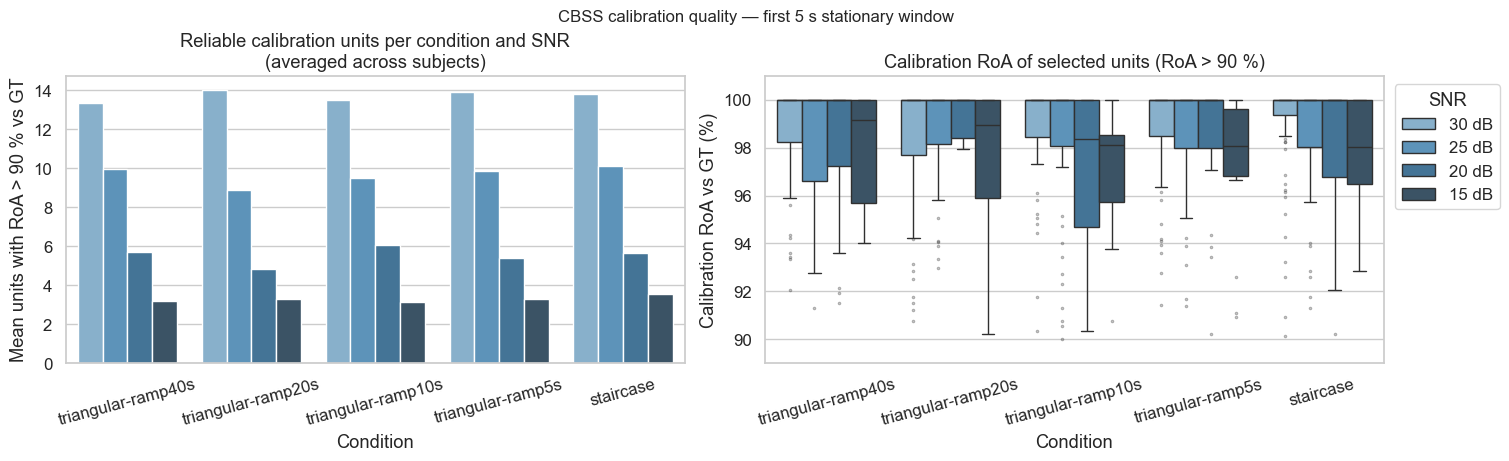

In [6]:
# ── Build calibration summary dataframe ───────────────────────────────────────
cal_rows = []
for (sub, cond, snr), cal in calibrations.items():
    if cal is None:
        continue
    for roa_val in cal['roa_kept']:
        cal_rows.append({
            'sub':       sub,
            'condition': cond,
            'snr':       snr,
            'n_kept':    cal['n_kept'],
            'roa_cal':   float(roa_val) * 100,
        })

df_cal = pd.DataFrame(cal_rows)

snr_order = [f'{s} dB' for s in SNR_LEVELS]
df_cal['SNR'] = df_cal['snr'].astype(str) + ' dB'

# ── Plot ───────────────────────────────────────────────────────────────────────
fig, axs = plt.subplots(1, 2, figsize=(15, 4.5), layout='constrained')

# Left: mean number of reliably detected units per condition × SNR
n_units_mean = (
    df_cal.groupby(['condition', 'SNR'])['n_kept']
    .mean().reset_index()
)
sns.barplot(
    data=n_units_mean, x='condition', y='n_kept', hue='SNR',
    hue_order=snr_order, order=CONDITIONS,
    palette='Blues_d', ax=axs[0], legend=False
)
axs[0].set(
    ylabel=f'Mean units with RoA > {int(ROA_CAL_TH*100)} % vs GT',
    xlabel='Condition',
    title='Reliable calibration units per condition and SNR\n(averaged across subjects)',
)
axs[0].tick_params(axis='x', rotation=15)

# Right: distribution of calibration RoA for selected units
sns.boxplot(
    data=df_cal, x='condition', y='roa_cal', hue='SNR',
    hue_order=snr_order, order=CONDITIONS,
    palette='Blues_d',
    flierprops=dict(marker='.', markersize=3, alpha=0.4),
    ax=axs[1],
)
axs[1].set(
    ylabel='Calibration RoA vs GT (%)',
    xlabel='Condition',
    title=f'Calibration RoA of selected units (RoA > {int(ROA_CAL_TH*100)} %)',
    ylim=(ROA_CAL_TH * 100 - 1, 101),
)
axs[1].tick_params(axis='x', rotation=15)
axs[1].legend(title='SNR', loc='upper right', bbox_to_anchor=(1.2, 1.0))

plt.suptitle('CBSS calibration quality — first 5 s stationary window', fontsize=12)
plt.show()


### Sanity check -- calibration preprocessing power spectrum

Power spectrum of the raw calibration-window EMG vs. the same window run through
preprocess_emg() directly (bandpass 20-500 Hz + harmonic notch, same parameters CBSS
calibration uses). No CBSS decomposition involved -- just the filter, in isolation.
Confirms the notch removes only a narrow band around 50/100/150 Hz -- not the ~+/-30 Hz
the old notch_quality_factor bug used to remove per harmonic.


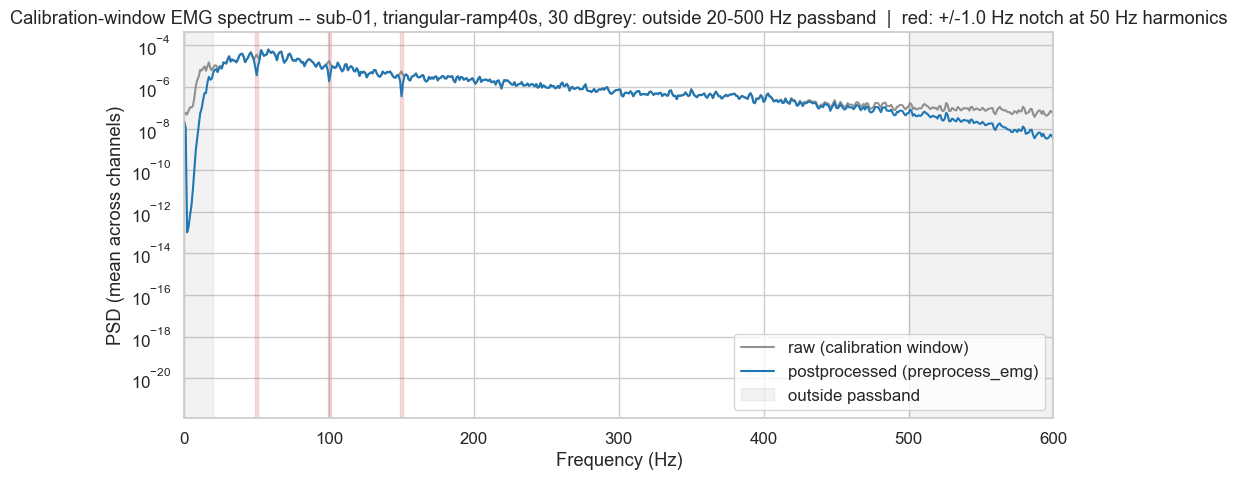

RMS  raw: 0.0524   postprocessed: 0.0491   ratio: 0.94x


In [7]:
PSD_SUB, PSD_COND, PSD_SNR = OPTIM_SUB, TRIANGULAR[0], OPTIM_SNR

from scipy.signal import welch
from adapt_decomp.preprocessing import preprocess_emg

_raw = load_raw_recording(FDSI_ROOT, PSD_SUB, PSD_COND, PSD_SNR)
_emg_raw_cal = _raw['emg_full'][:CAL_END].astype(np.float64)

_emg_post_cal = preprocess_emg(
    _emg_raw_cal, fs=CBSS_CFG.fs,
    highpass=CBSS_CFG.lowcut,
    lowpass=CBSS_CFG.highcut,
    filter_order=CBSS_CFG.filter_order,
    notch_filter=CBSS_CFG.powerline,
    notch_freq=CBSS_CFG.powerline_freq,
    notch_width_hz=CBSS_CFG.notch_width_hz,
    notch_n_harmonics=CBSS_CFG.notch_n_harmonics,
    notch_order=CBSS_CFG.notch_order,
).astype(np.float64)

def _mean_psd(emg, fs, nperseg=2048):
    freqs, pxx = welch(emg, fs=fs, nperseg=nperseg, axis=0)
    return freqs, pxx.mean(axis=1)

f_raw,  p_raw  = _mean_psd(_emg_raw_cal,  FS)
f_post, p_post = _mean_psd(_emg_post_cal, FS)

fig, ax = plt.subplots(figsize=(10, 5))
ax.semilogy(f_raw,  p_raw,  label='raw (calibration window)',       color='tab:gray', alpha=0.85)
ax.semilogy(f_post, p_post, label='postprocessed (preprocess_emg)', color='tab:blue')
ax.axvspan(0, CBSS_CFG.lowcut, color='grey', alpha=0.10, label='outside passband')
ax.axvspan(CBSS_CFG.highcut, FS / 2, color='grey', alpha=0.10)
for _h in CBSS_CFG.powerline_freq * np.arange(1, CBSS_CFG.notch_n_harmonics + 1):
    ax.axvspan(_h - CBSS_CFG.notch_width_hz, _h + CBSS_CFG.notch_width_hz,
               color='tab:red', alpha=0.15)
ax.set(
    xlim=(0, 600), xlabel='Frequency (Hz)', ylabel='PSD (mean across channels)',
    title=(f'Calibration-window EMG spectrum -- {PSD_SUB}, {PSD_COND}, {PSD_SNR} dB'
           f'grey: outside {CBSS_CFG.lowcut:.0f}-{CBSS_CFG.highcut:.0f} Hz passband  |  '
           f'red: +/-{CBSS_CFG.notch_width_hz:.1f} Hz notch at {CBSS_CFG.powerline_freq:.0f} Hz harmonics'),
)
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

_rms_raw  = np.sqrt((_emg_raw_cal  ** 2).mean())
_rms_post = np.sqrt((_emg_post_cal ** 2).mean())
print(f'RMS  raw: {_rms_raw:.4f}   postprocessed: {_rms_post:.4f}   ratio: {_rms_post / _rms_raw:.2f}x')


## 3. Hyperparameter optimisation — per contraction condition

CMA-ES (single-objective: `wh_loss + sv_loss`) is run for `sub-01` at 30 dB SNR, independently for each contraction condition.  Best configs are saved to `OPT_DIR` and reloaded when `RUN_OPTIMISATION = False`.

In [8]:
best_configs = {}   # cond → full best-config dict (base + optimised params)
studies      = {}   # cond → Optuna study object (None when loaded from file)

def _t(arr):
    return torch.tensor(np.asarray(arr), dtype=torch.float32)

for cond in CONDITIONS:
    opt_key  = (OPTIM_SUB, cond, OPTIM_SNR)
    opt_path = OPT_DIR / f'best_config_{cond}.json'
    cal      = calibrations.get(opt_key)

    if cal is None:
        print(f'[SKIP] {opt_key}: no calibration')
        best_configs[cond] = None
        studies[cond]      = None
        continue

    if RUN_OPTIMISATION or not opt_path.exists():
        raw      = load_raw_recording(FDSI_ROOT, OPTIM_SUB, cond, OPTIM_SNR)
        emg_full = raw['emg_full']
        filt     = cal['filtered_cal']

        # preprocess=True: AdaptDecomp.Data now shares preprocessing.preprocess_emg
        # with CBSS calibration (previously two different filters -- CBSS zero-phase
        # with a mis-scaled notch, AdaptDecomp a different causal one -- put the
        # whitening reference and the online covariance on different EMG scales and
        # inflated wh_loss to ~1e9 regardless of hyperparameters, drowning out
        # sv_loss). Requires calibrations recomputed under the fixed notch width
        # (RUN_CAL=True) -- calibrations cached under the old 30 Hz notch bug are stale.
        best_config, study = optimize_adapt_decomp(
            emg             = _t(emg_full),
            whitening       = _t(filt.whitening),
            sep_vectors     = _t(filt.sep_vectors).T.contiguous(),  # [dim,n_mu]→[n_mu,dim]
            base_centroids  = _t(filt.base_centr),
            spike_centroids = _t(filt.spikes_centr),
            emg_calib       = _t(filt.emg),
            ipts_calib      = _t(filt.sources),
            spikes_calib    = _t(filt.spikes),
            param_space     = OPT_PARAM_SPACE,
            base_config     = OPT_BASE_CONFIG,
            n_trials        = N_OPT_TRIALS,
            preprocess      = True,
        )
        with open(opt_path, 'w') as f:
            json.dump({k: _to_json_safe(v) for k, v in best_config.items()}, f, indent=2)
        pd.DataFrame([
            {'trial': t.number, 'value': t.value, **t.params}
            for t in study.trials if t.value is not None
        ]).to_csv(opt_path.with_suffix('.csv'), index=False)
        print(f'[{cond}] optimised → {opt_path}')
    else:
        with open(opt_path) as f:
            best_config = json.load(f)
        study = None
        print(f'[{cond}] loaded from {opt_path}')

    best_configs[cond] = best_config
    studies[cond]      = study
    for k in OPT_PARAM_SPACE:
        print(f'    {k}: {best_config[k]:.4e}')


[triangular-ramp40s] loaded from ..\data\fdsi_results\lr_kl_to_cal_penalty\optimisation\best_config_triangular-ramp40s.json
    lr_v: 1.0415e-04
    lr_b: 1.8849e-03
[triangular-ramp20s] loaded from ..\data\fdsi_results\lr_kl_to_cal_penalty\optimisation\best_config_triangular-ramp20s.json
    lr_v: 1.1146e-04
    lr_b: 7.3819e-04
[triangular-ramp10s] loaded from ..\data\fdsi_results\lr_kl_to_cal_penalty\optimisation\best_config_triangular-ramp10s.json
    lr_v: 1.1799e-04
    lr_b: 5.2555e-03
[triangular-ramp5s] loaded from ..\data\fdsi_results\lr_kl_to_cal_penalty\optimisation\best_config_triangular-ramp5s.json
    lr_v: 1.1124e-04
    lr_b: 3.4610e-03
[staircase] loaded from ..\data\fdsi_results\lr_kl_to_cal_penalty\optimisation\best_config_staircase.json
    lr_v: 1.0702e-04
    lr_b: 1.3640e-04


In [9]:
# ── Optimisation history: loss vs trial, one column per condition ──────────────
conds_with_study = [c for c in CONDITIONS if studies.get(c) is not None]

if conds_with_study:
    n_cols = len(conds_with_study)
    fig, axs = plt.subplots(1, n_cols, figsize=(4 * n_cols, 3.5), layout='constrained')
    if n_cols == 1:
        axs = [axs]

    for ax, cond in zip(axs, conds_with_study):
        study  = studies[cond]
        trials = [t for t in study.trials if t.value is not None]
        xs     = [t.number   for t in trials]
        ys     = [t.value    for t in trials]
        best   = np.minimum.accumulate(ys)

        ax.scatter(xs, ys, s=18, alpha=0.55, color='steelblue', zorder=2, label='trial loss')
        ax.plot(xs, best, color='tab:orange', linewidth=1.5, label='best so far')
        best_idx = int(np.argmin(ys))
        ax.scatter([xs[best_idx]], [ys[best_idx]], marker='*', s=200,
                   color='tab:red', zorder=5, label='optimum')
        ax.set(title=cond, xlabel='Trial', ylabel='Loss',
               ylim=(min(ys) * 0.5, max(ys) * 0.05))
        ax.legend(fontsize=8)

    plt.suptitle(
        f'Optimisation history — {OPTIM_SUB}, {OPTIM_SNR} dB (CMA-ES, {N_OPT_TRIALS} trials)',
        fontsize=12,
    )
    plt.show()
else:
    print('No Optuna study objects available (all loaded from file).')


No Optuna study objects available (all loaded from file).


In [10]:
# ── Parameter vs loss scatter, one row per param, one column per condition ─────
LOG_PARAMS = {'lr_v', 'lr_b'}   # show on log x-axis
param_names = list(OPT_PARAM_SPACE.keys())

if conds_with_study:
    n_params = len(param_names)
    fig, axs = plt.subplots(n_params, len(conds_with_study),
                             figsize=(4 * len(conds_with_study), 3 * n_params),
                             layout='constrained', squeeze=False)

    for col, cond in enumerate(conds_with_study):
        study  = studies[cond]
        trials = [t for t in study.trials if t.value is not None]
        ys     = np.array([t.value for t in trials])
        trial_idx = np.arange(len(trials))

        for row, pname in enumerate(param_names):
            ax = axs[row, col]
            xs = np.array([t.params[pname] for t in trials])
            sc = ax.scatter(xs, ys, c=trial_idx, cmap='viridis', s=20, alpha=0.7)
            best_t = trials[int(np.argmin(ys))]
            ax.axvline(best_t.params[pname], color='tab:red', linestyle='--', linewidth=1.2)

            if pname in LOG_PARAMS:
                ax.set_xscale('log')
            ax.set(ylabel='Loss' if col == 0 else '',
                   xlabel=pname,
                   title=f'{cond}' if row == 0 else '',)
            plt.colorbar(sc, ax=ax, label='trial' if col == len(conds_with_study) - 1 else '')
            
    plt.suptitle(
        f'Hyperparameter sensitivity — {OPTIM_SUB}, {OPTIM_SNR} dB\n'
        '(colour = trial index; dashed = optimum)',
        fontsize=12,
    )
    plt.show()


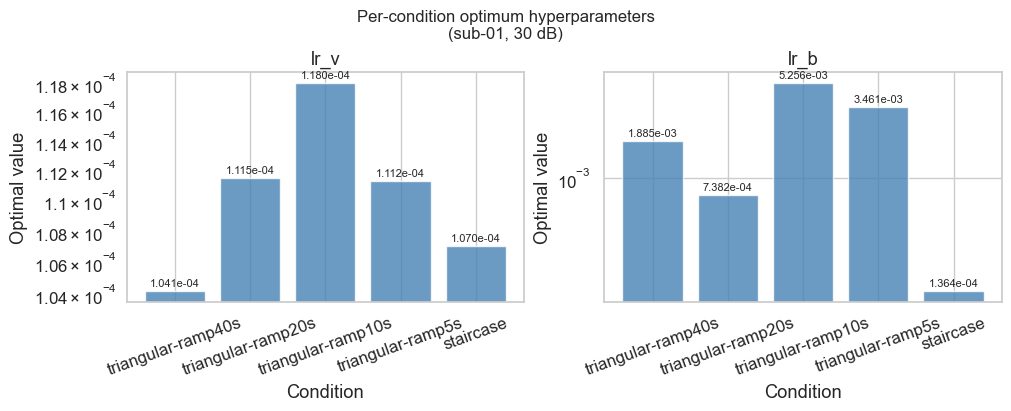

In [11]:
# ── Bar chart of optimum hyperparameter values per condition ───────────────────
valid_conds = [c for c in CONDITIONS if best_configs.get(c) is not None]

if valid_conds:
    n_params = len(param_names)
    fig, axs = plt.subplots(1, n_params, figsize=(5 * n_params, 4), layout='constrained')
    if n_params == 1:
        axs = [axs]

    for ax, pname in zip(axs, param_names):
        vals  = [best_configs[c][pname] for c in valid_conds]
        bars  = ax.bar(valid_conds, vals, color='steelblue', alpha=0.8)
        ax.bar_label(bars, fmt='%.3e', fontsize=8, padding=2)
        if pname in LOG_PARAMS:
            ax.set_yscale('log')
        ax.set(title=pname, xlabel='Condition', ylabel='Optimal value')
        ax.tick_params(axis='x', rotation=20)

    plt.suptitle(
        f'Per-condition optimum hyperparameters\n({OPTIM_SUB}, {OPTIM_SNR} dB)',
        fontsize=12,
    )
    plt.show()


## 4. Adaptation — fixed and adapted decomposition

For each recording with a valid calibration:
1. **Fixed** — `AdaptDecomp.from_calibration(adapt=False)` on the full recording; no online updates.
2. **Adapted** — `AdaptDecomp.from_calibration(adapt=True)` on the full recording using the **per-condition best hyperparameters** found in §3.
3. **Overall RoA** — `rate_of_agreement_paired` over the **full recording** (calibration + adaptation).
4. **Phase RoA** (triangular only) — fixed 5-s windows: first iso (cal + first 5 s) · ramp · last 5 s.

Full-recording spike arrays are saved to disk; RoA is pre-computed per phase.

In [12]:
results = {}

pbar = tqdm(
    total=sum(1 for v in calibrations.values() if v is not None),
    desc='AdaptDecomp',
)

for sub in SUBJECTS:
    for cond in CONDITIONS:
        for snr in SNR_LEVELS:
            key = (sub, cond, snr)
            cal = calibrations.get(key)
            if cal is None:
                results[key] = None
                continue

            cache_dir   = RESULTS_DIR / sub / cond
            fixed_path  = cache_dir / f'snr{snr}dB_fixed_spikes.npz'
            adapt_path  = cache_dir / f'snr{snr}dB_adapted_spikes.npz'
            roa_path    = cache_dir / f'snr{snr}dB_roa_labels.npz'

            raw          = load_raw_recording(FDSI_ROOT, sub, cond, snr)
            emg_full     = raw['emg_full']
            spikes_obj   = raw['spikes_obj']
            filtered_cal = cal['filtered_cal']
            gt_matched   = cal['gt_matched']
            n_kept       = cal['n_kept']
            n_full       = emg_full.shape[0]

            gt_full_bin = build_gt_full_binary_paired(spikes_obj, gt_matched, n_full)

            # ── Fixed (no online adaptation) ──────────────────────────────────
            # preprocess=True: see note in §3 -- AdaptDecomp.Data and CBSS calibration
            # now share the same preprocessing.preprocess_emg().
            if RUN_DECOMP or not fixed_path.exists():
                dec = AdaptDecomp.from_calibration(
                    emg         = emg_full,
                    calibration = filtered_cal,
                    config      = make_adapt_config(CBSS_CFG.ext_fact, adapt=False),
                    preprocess  = True,
                )
                full_fixed = dec.run()['spikes'].numpy().astype(np.float32)
                np.savez_compressed(fixed_path, spikes=full_fixed, gt_matched_indices=gt_matched)
            else:
                _f         = np.load(fixed_path)
                full_fixed = _f['spikes'].astype(np.float32)
                gt_matched = _f['gt_matched_indices']
                n_kept     = full_fixed.shape[1]
                gt_full_bin = build_gt_full_binary_paired(spikes_obj, gt_matched, n_full)

            # ── Adapted — per-condition best hyperparameters ──────────────────
            best_cfg = best_configs.get(cond)
            if RUN_DECOMP or not adapt_path.exists():
                adapt_config = make_adapt_config(CBSS_CFG.ext_fact, adapt=True)
                if best_cfg is not None:
                    for k, v in best_cfg.items():
                        if hasattr(adapt_config, k):
                            setattr(adapt_config, k, v)
                dec = AdaptDecomp.from_calibration(
                    emg         = emg_full,
                    calibration = filtered_cal,
                    config      = adapt_config,
                    preprocess  = True,
                )
                full_adapted = dec.run()['spikes'].numpy().astype(np.float32)
                np.savez_compressed(adapt_path, spikes=full_adapted, gt_matched_indices=gt_matched)
            else:
                full_adapted = np.load(adapt_path)['spikes'].astype(np.float32)

            # ── Overall RoA — full recording (calibration + adaptation) ────────
            roa_fixed,   _, _ = rate_of_agreement_paired(gt_full_bin, full_fixed,   fs=FS, tol_spike_ms=2)
            roa_adapted, _, _ = rate_of_agreement_paired(gt_full_bin, full_adapted, fs=FS, tol_spike_ms=2)
            np.savez_compressed(roa_path, roa_fixed=roa_fixed, roa_adapted=roa_adapted,
                                gt_matched_indices=gt_matched)

            # ── Phase RoA for triangular conditions ────────────────────────────
            phase_roa = {}
            if cond in TRIANGULAR:
                phases = get_triangular_phases(n_full)
                for phase_name, s in phases.items():
                    phase_roa[phase_name] = {
                        'fixed':   compute_roa_subset(gt_full_bin, full_fixed,   s),
                        'adapted': compute_roa_subset(gt_full_bin, full_adapted, s),
                    }

            results[key] = {
                'roa_fixed':   roa_fixed,
                'roa_adapted': roa_adapted,
                'phase_roa':   phase_roa,
                'gt_matched':  gt_matched,
                'angle_full':  raw['angle'],
                'n_full':      n_full,
                'n_kept':      n_kept,
                'roa_kept':    cal['roa_kept'],
            }
            pbar.update(1)

pbar.close()
n_done = sum(1 for v in results.values() if v is not None)
print(f'Done.  {n_done}/{len(results)} recordings processed.')


AdaptDecomp:   0%|          | 0/100 [00:00<?, ?it/s]

Done.  100/100 recordings processed.


## 5. Overall RoA — fixed vs adapted, all conditions and SNR levels

RoA is computed over the **full recording** (calibration + adaptation) so that the initial stationary period is included in the baseline.  The adapted run uses per-condition hyperparameters found in §3.

In [13]:
rows = []
for (sub, cond, snr), res in results.items():
    if res is None:
        continue
    for u, (rf, ra) in enumerate(zip(res['roa_fixed'], res['roa_adapted'])):
        rows.append({
            'sub':       sub,
            'condition': cond,
            'snr':       snr,
            'unit':      u,
            'roa_fixed':   float(rf),
            'roa_adapted': float(ra),
            'roa_cal':     float(res['roa_kept'][u]),  # calibration-window RoA, same unit order
        })

df = pd.DataFrame(rows)
df['roa_fixed_pct']   = df['roa_fixed']   * 100
df['roa_adapted_pct'] = df['roa_adapted'] * 100
df['roa_cal_pct']     = df['roa_cal']     * 100

print('Mean RoA (%) — fixed vs adapted, by condition and SNR (averaged across subjects and units):')
print(
    df.groupby(['condition', 'snr'])[['roa_fixed_pct', 'roa_adapted_pct']]
    .mean().round(2).to_string()
)

Mean RoA (%) — fixed vs adapted, by condition and SNR (averaged across subjects and units):
                        roa_fixed_pct  roa_adapted_pct
condition          snr                                
staircase          15           35.26            69.98
                   20           35.19            67.93
                   25           32.99            62.81
                   30           32.99            62.34
triangular-ramp10s 15           39.88            70.34
                   20           38.07            67.06
                   25           37.39            64.76
                   30           37.07            65.57
triangular-ramp20s 15           40.72            72.13
                   20           40.91            71.72
                   25           37.84            65.74
                   30           37.64            63.64
triangular-ramp40s 15           41.10            84.50
                   20           40.08            85.56
                   25       

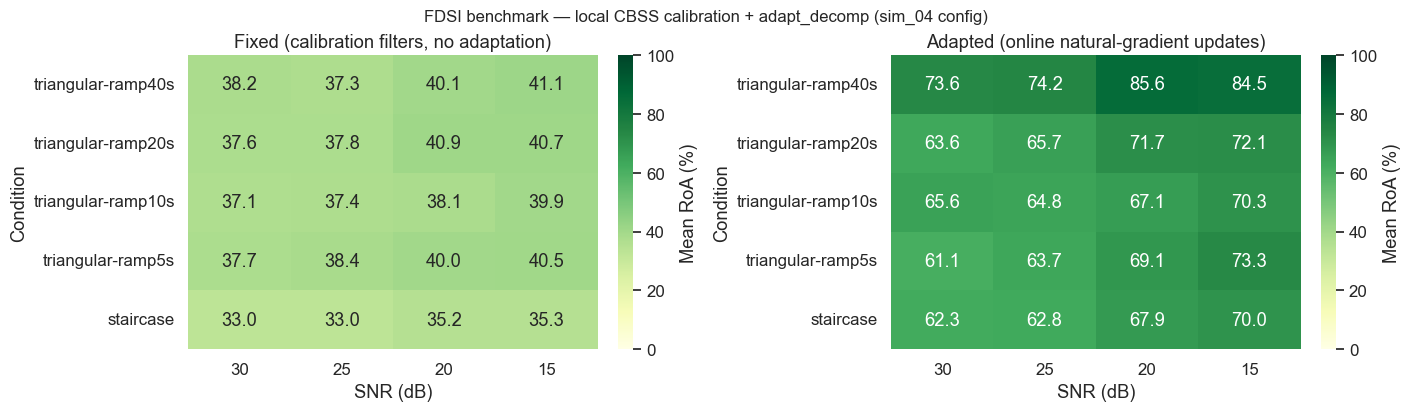

In [14]:
# Heatmaps: mean RoA per condition × SNR — fixed vs adapted side by side
fig, axs = plt.subplots(1, 2, figsize=(14, 4), layout='constrained')
for ax, col, title in [
    (axs[0], 'roa_fixed_pct',   'Fixed (calibration filters, no adaptation)'),
    (axs[1], 'roa_adapted_pct', 'Adapted (online natural-gradient updates)'),
]:
    pivot = df.groupby(['condition', 'snr'])[col].mean().unstack('snr')
    pivot = pivot.reindex(index=CONDITIONS, columns=SNR_LEVELS)
    sns.heatmap(
        pivot, annot=True, fmt='.1f', cmap='YlGn',
        vmin=0, vmax=100, ax=ax,
        cbar_kws={'label': 'Mean RoA (%)'},
    )
    ax.set(title=title, xlabel='SNR (dB)', ylabel='Condition')

plt.suptitle(
    'FDSI benchmark — local CBSS calibration + adapt_decomp (sim_04 config)',
    fontsize=12,
)
plt.show()

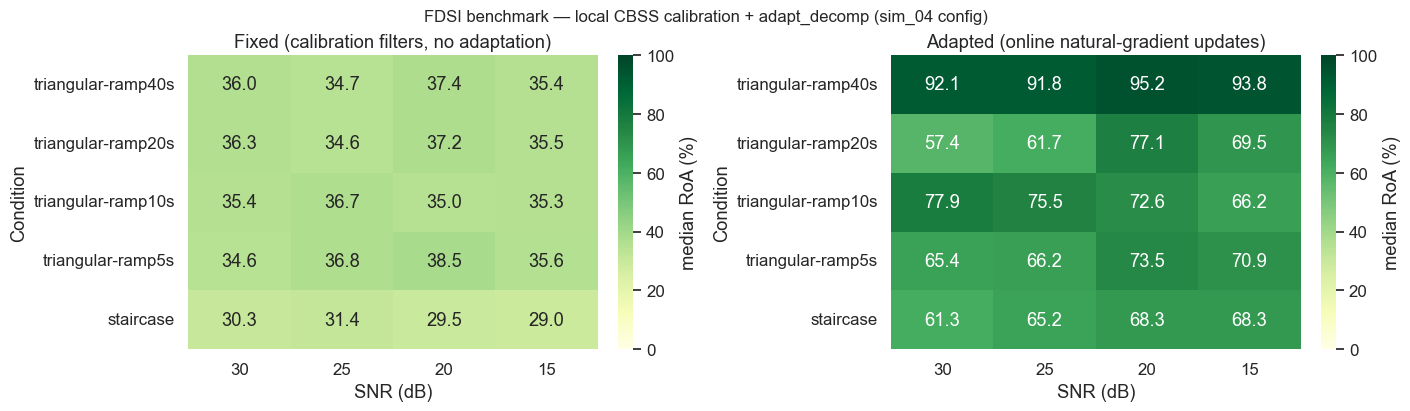

In [15]:
# Heatmaps: median RoA per condition × SNR — fixed vs adapted side by side
fig, axs = plt.subplots(1, 2, figsize=(14, 4), layout='constrained')
for ax, col, title in [
    (axs[0], 'roa_fixed_pct',   'Fixed (calibration filters, no adaptation)'),
    (axs[1], 'roa_adapted_pct', 'Adapted (online natural-gradient updates)'),
]:
    pivot = df.groupby(['condition', 'snr'])[col].median().unstack('snr')
    pivot = pivot.reindex(index=CONDITIONS, columns=SNR_LEVELS)
    sns.heatmap(
        pivot, annot=True, fmt='.1f', cmap='YlGn',
        vmin=0, vmax=100, ax=ax,
        cbar_kws={'label': 'median RoA (%)'},
    )
    ax.set(title=title, xlabel='SNR (dB)', ylabel='Condition')

plt.suptitle(
    'FDSI benchmark — local CBSS calibration + adapt_decomp (sim_04 config)',
    fontsize=12,
)
plt.show()

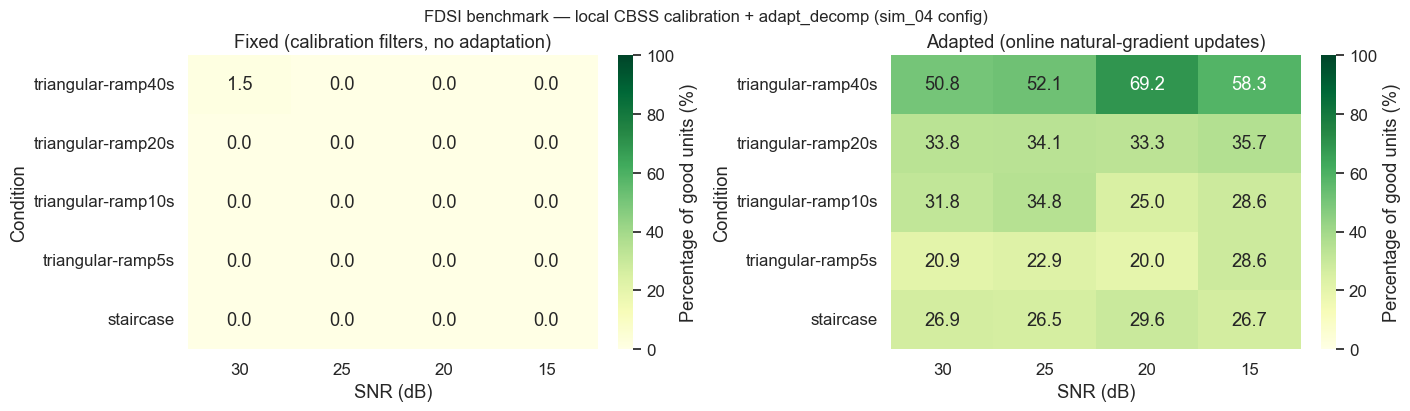

In [16]:
# Heatmaps: Percentage of good units (RoA >= 0.9) × SNR — fixed vs adapted side by side
fig, axs = plt.subplots(1, 2, figsize=(14, 4), layout='constrained')
for ax, col, title in [
    (axs[0], 'roa_fixed_pct',   'Fixed (calibration filters, no adaptation)'),
    (axs[1], 'roa_adapted_pct', 'Adapted (online natural-gradient updates)'),
]:
    pivot = df.groupby(['condition', 'snr'])[col].apply(lambda x: (x >= 90).sum() / len(x) * 100).unstack('snr')
    pivot = pivot.reindex(index=CONDITIONS, columns=SNR_LEVELS)
    sns.heatmap(
        pivot, annot=True, fmt='.1f', cmap='YlGn',
        vmin=0, vmax=100, ax=ax,
        cbar_kws={'label': 'Percentage of good units (%)'},
    )
    ax.set(title=title, xlabel='SNR (dB)', ylabel='Condition')

plt.suptitle(
    'FDSI benchmark — local CBSS calibration + adapt_decomp (sim_04 config)',
    fontsize=12,
)
plt.show()

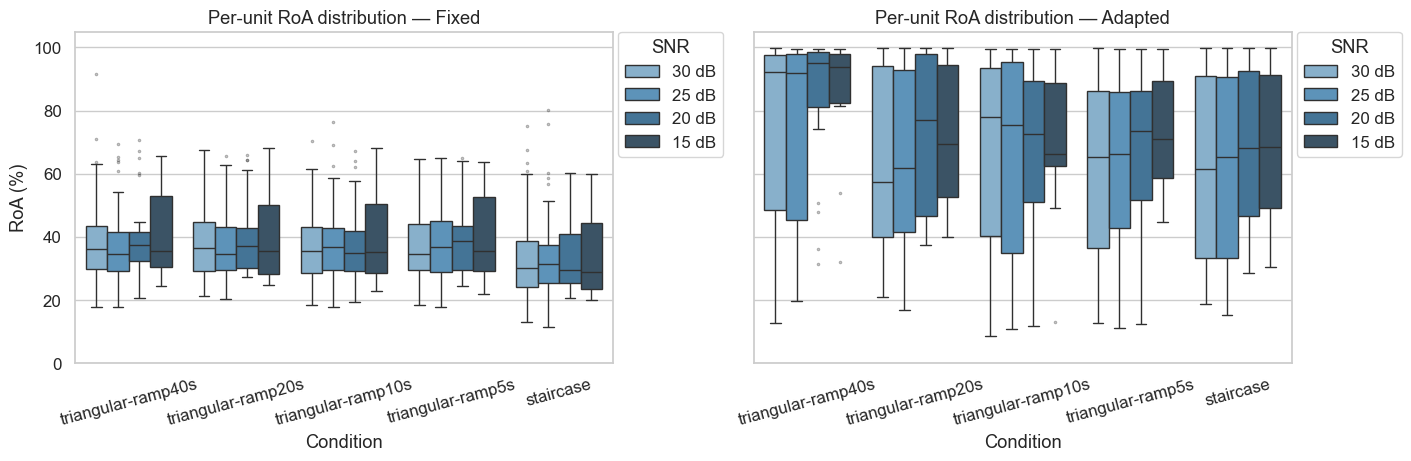

In [17]:
# Box plot: per-unit RoA distribution — fixed vs adapted, by condition and SNR
df_melt = df.melt(
    id_vars=['sub', 'condition', 'snr', 'unit'],
    value_vars=['roa_fixed_pct', 'roa_adapted_pct'],
    var_name='method', value_name='roa_pct',
)
df_melt['method'] = df_melt['method'].map({
    'roa_fixed_pct':   'Fixed',
    'roa_adapted_pct': 'Adapted',
})
df_melt['SNR'] = df_melt['snr'].astype(str) + ' dB'
snr_order = [f'{s} dB' for s in SNR_LEVELS]

fig, axs = plt.subplots(1, 2, figsize=(14, 4.5), layout='constrained', sharey=True)
for ax, method in zip(axs, ['Fixed', 'Adapted']):
    sub_df = df_melt[df_melt['method'] == method]
    sns.boxplot(
        data=sub_df, x='condition', y='roa_pct', hue='SNR',
        hue_order=snr_order, order=CONDITIONS,
        palette='Blues_d', flierprops=dict(marker='.', markersize=3, alpha=0.4),
        ax=ax,
    )
    ax.set(ylabel='RoA (%)', xlabel='Condition',
           title=f'Per-unit RoA distribution — {method}', ylim=(0, 105))
    ax.tick_params(axis='x', rotation=15)
    ax.legend(title='SNR', bbox_to_anchor=(1.01, 1), borderaxespad=0)
plt.show()

In [18]:
OPTIM_SUB, OPTIM_SNR

('sub-01', 30)

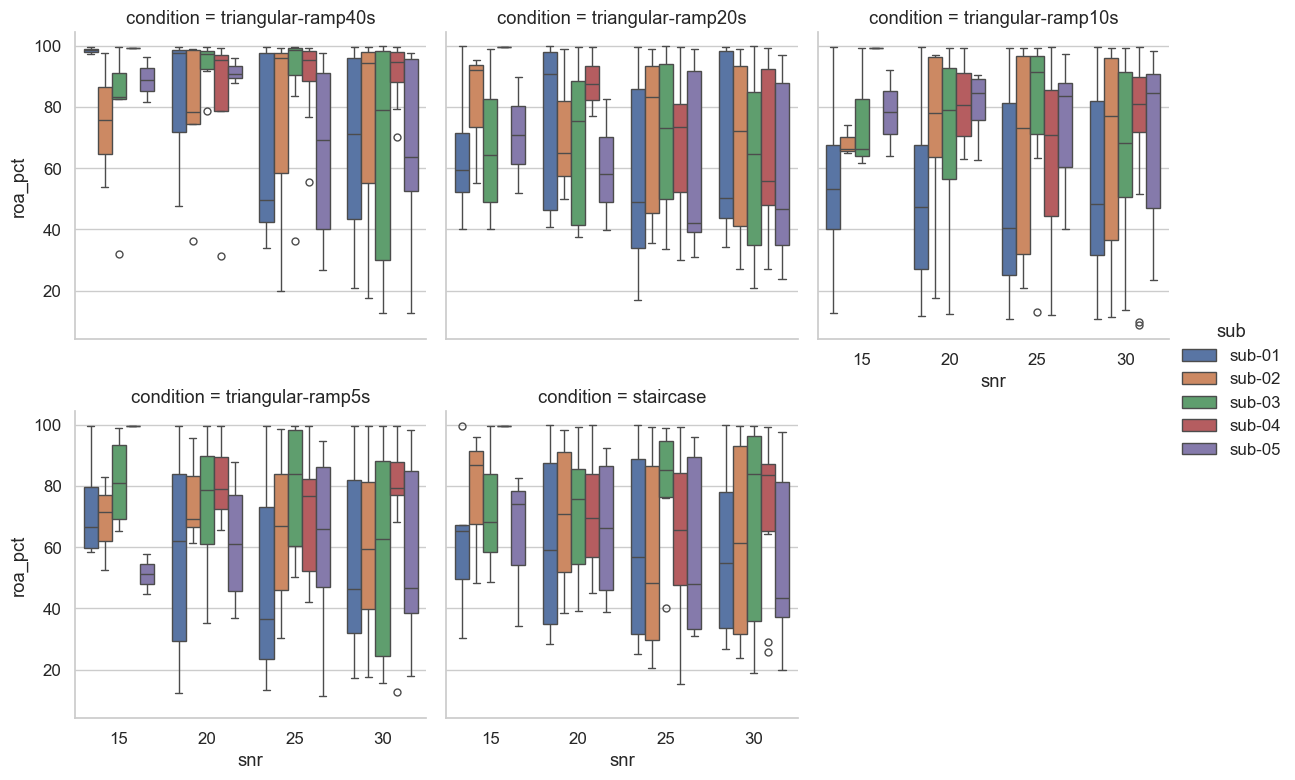

In [19]:
df_melt_adapt = df_melt[df_melt['method'] == 'Adapted']

g = sns.catplot(
    data=df_melt_adapt,
    x='snr', y='roa_pct', hue='sub',
    col = 'condition', col_wrap=3, sharey=True,
    kind="box", 
    margin_titles=True,
    height=4, aspect=1,
)

## 6. Phase RoA for triangular contractions

Three fixed-duration phases relative to the **full recording**:

| Phase | Samples | Duration |
|-------|---------|----------|
| **First isometric** | `[0, CAL_END)` | 5 s |
| **Triangular ramp** | `[CAL_END, n_full − ISO_DUR)` | recording-dependent |
| **Last isometric** | `[n_full − ISO_DUR, n_full)` | 5 s |

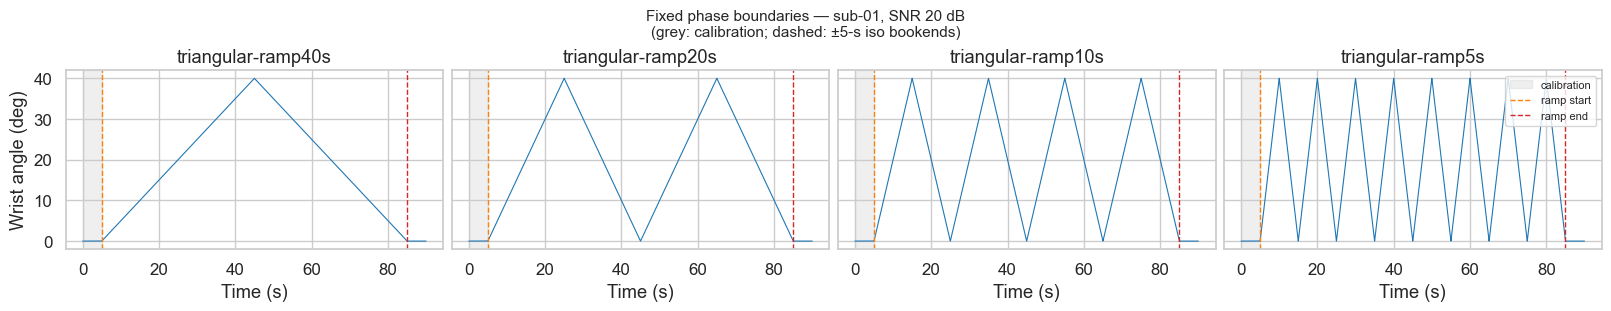

In [20]:
# Sanity check: full-recording angle profile with fixed phase boundaries
sub_check = 'sub-01'
snr_check = 20
n_tri     = len(TRIANGULAR)

fig, axs = plt.subplots(1, n_tri, figsize=(4 * n_tri, 3), layout='constrained', sharey=True)
for ax, cond in zip(axs, TRIANGULAR):
    key    = (sub_check, cond, snr_check)
    res    = results.get(key)
    if res is None:
        ax.set_title(f'{cond}\n[no data]')
        continue
    angle  = res['angle_full']
    n_full = res['n_full']
    t      = np.arange(n_full) / FS

    ramp_start_t = (CAL_END) / FS
    ramp_end_t   = (n_full - ISO_DUR) / FS

    ax.axvspan(0, CAL_END / FS, alpha=0.12, color='grey', zorder=0, label='calibration')
    ax.plot(t, angle, color='tab:blue', linewidth=0.8)
    ax.axvline(ramp_start_t, color='tab:orange', linestyle='--', linewidth=1, label='ramp start')
    ax.axvline(ramp_end_t,   color='tab:red',    linestyle='--', linewidth=1, label='ramp end')
    ax.set(title=cond, xlabel='Time (s)')

axs[0].set_ylabel('Wrist angle (deg)')
axs[-1].legend(fontsize=8, loc='upper right')
plt.suptitle(
    f'Fixed phase boundaries — {sub_check}, SNR {snr_check} dB\n'
    f'(grey: calibration; dashed: ±{ISO_DUR/FS:.0f}-s iso bookends)',
    fontsize=11,
)
plt.show()


In [21]:
PHASE_ORDER  = ['first_iso', 'ramp', 'last_iso']
PHASE_LABELS = {
    'first_iso': f'First iso\n(first {ISO_DUR//FS} s)',
    'ramp':      'Triangular ramp',
    'last_iso':  f'Last iso\n(last {ISO_DUR//FS} s)',
}

phase_rows = []
for (sub, cond, snr), res in results.items():
    if res is None or cond not in TRIANGULAR:
        continue
    for phase_name in PHASE_ORDER:
        roa_f = res['phase_roa'][phase_name]['fixed']
        roa_a = res['phase_roa'][phase_name]['adapted']
        for u, (rf, ra) in enumerate(zip(roa_f, roa_a)):
            phase_rows.append({
                'sub':         sub,
                'condition':   cond,
                'snr':         snr,
                'phase':       phase_name,
                'unit':        u,
                'roa_fixed':   float(rf),
                'roa_adapted': float(ra),
            })

df_phase = pd.DataFrame(phase_rows)
df_phase['roa_fixed_pct']   = df_phase['roa_fixed']   * 100
df_phase['roa_adapted_pct'] = df_phase['roa_adapted'] * 100
df_phase['phase'] = pd.Categorical(df_phase['phase'], categories=PHASE_ORDER, ordered=True)
print(f'Phase-RoA rows: {len(df_phase)}')


Phase-RoA rows: 1818


In [22]:
# Summary tables per triangular condition — fixed vs adapted per phase
for cond in TRIANGULAR:
    df_c = df_phase[df_phase['condition'] == cond]
    tbl  = (
        df_c.groupby(['snr', 'phase'], observed=True)[['roa_fixed_pct', 'roa_adapted_pct']]
        .mean().round(2)
        .unstack('phase')
    )
    tbl.columns = [f'{m.replace("roa_","").replace("_pct","")} ({p})' for m, p in tbl.columns]
    col_order = [f'{m} ({p})'
                 for p in PHASE_ORDER
                 for m in ['fixed', 'adapted']]
    tbl = tbl[[c for c in col_order if c in tbl.columns]]
    print(f'\n=== {cond} ===')
    print(tbl.to_string())
    print()


=== triangular-ramp40s ===
     fixed (first_iso)  adapted (first_iso)  fixed (ramp)  adapted (ramp)  fixed (last_iso)  adapted (last_iso)
snr                                                                                                            
15               94.18                96.86         30.54           83.24             92.79               86.84
20               95.06                96.67         29.08           84.58             95.26               85.43
25               95.70                97.24         25.98           72.12             95.64               82.47
30               97.29                98.32         26.85           71.41             97.42               79.47


=== triangular-ramp20s ===
     fixed (first_iso)  adapted (first_iso)  fixed (ramp)  adapted (ramp)  fixed (last_iso)  adapted (last_iso)
snr                                                                                                            
15               90.35                94.67    

In [ ]:
# Phase bar chart — fixed vs adapted, one row per method, one column per condition
n_tri = len(TRIANGULAR)
fig, axs = plt.subplots(2, n_tri, figsize=(5 * n_tri, 8),
                         layout='constrained', sharey=True)

for row, (method_col, method_label) in enumerate([
    ('roa_fixed_pct',   'Fixed'),
    ('roa_adapted_pct', 'Adapted'),
]):
    for col, cond in enumerate(TRIANGULAR):
        ax     = axs[row, col]
        df_c = df_phase[df_phase['condition'] == cond].copy()
        df_c['SNR'] = df_c['snr'].astype(str) + ' dB'
        sns.barplot(
            data=df_c, x='phase', y=method_col, hue='SNR',
            hue_order=[f'{s} dB' for s in SNR_LEVELS], order=PHASE_ORDER,
            estimator='mean', errorbar='sd', capsize=0.1,
            palette='Blues_d', ax=ax,
        )
        ax.set(xlabel='', ylabel='Mean RoA (%)', title=f'{method_label} — {cond}', ylim=(0, 105))
        ax.set_xticks(range(len(PHASE_ORDER)))
        ax.set_xticklabels([PHASE_LABELS[p] for p in PHASE_ORDER],
                           rotation=20, ha='right', fontsize=9)
        if col != 0:
            ax.set_ylabel('')
            ax.get_legend().remove()

plt.suptitle(
    'Three-phase RoA for triangular contractions — fixed vs adapted\n'
    '(averaged across subjects and units)',
    fontsize=12,
)
plt.show()

## 7. Summary figure

In [ ]:
colors_snr = {30: '#1a237e', 25: '#1565c0', 20: '#42a5f5', 15: '#b3e5fc'}

fig, axs = plt.subplots(2, 2, figsize=(15, 9), layout='constrained')

for row, (method_col, method_label) in enumerate([
    ('roa_fixed_pct',   'Fixed'),
    ('roa_adapted_pct', 'Adapted'),
]):
    # ── Left: overall mean RoA per condition, one line per SNR ───────────────
    stats_by = df.groupby(['condition', 'snr'])[method_col].agg(['mean', 'std']).reset_index()
    for snr in SNR_LEVELS:
        sub_df = stats_by[stats_by['snr'] == snr].set_index('condition').reindex(CONDITIONS)
        axs[row, 0].errorbar(
            CONDITIONS, sub_df['mean'], yerr=sub_df['std'],
            marker='o', capsize=3, label=f'{snr} dB', color=colors_snr[snr],
        )
    axs[row, 0].set(
        ylabel='Mean RoA (%)',
        title=f'Overall RoA — {method_label}',
        ylim=(0, 105), xlabel='Condition',
    )
    axs[row, 0].tick_params(axis='x', rotation=20)
    axs[row, 0].legend(title='SNR', fontsize=9)

    # ── Right: three-phase RoA averaged over all triangular conditions ────────
    phase_df = df_phase.copy()
    phase_df['SNR'] = phase_df['snr'].astype(str) + ' dB'
    sns.barplot(
        data=phase_df, x='phase', y=method_col, hue='SNR',
        hue_order=[f'{s} dB' for s in SNR_LEVELS], order=PHASE_ORDER,
        estimator='mean', errorbar='sd', capsize=0.1,
        palette='Blues_d', ax=axs[row, 1],
    )
    axs[row, 1].set_xticks(range(len(PHASE_ORDER)))
    axs[row, 1].set_xticklabels([PHASE_LABELS[p] for p in PHASE_ORDER],
                                  rotation=20, ha='right')
    axs[row, 1].set(
        ylabel='Mean RoA (%)',
        title=f'Phase RoA (triangular) — {method_label}',
        ylim=(0, 105), xlabel='',
    )

plt.suptitle(
    'FDSI benchmark — local CBSS calibration + adapt_decomp (sim_04 config)\n'
    'Fixed (frozen calibration filters) vs Adapted (online updates)',
    fontsize=12,
)
plt.show()

## 8. Clipping diagnostics and calibration-RoA correlation

Two follow-up questions, now under the `lr_v`/`lr_b` mechanism:

1. **Is the safety clip actually rare now?** Before this mechanism, `max_rel_delta_{v,b}` acted as the *entire* step size and was measured (in `fdsi_05`) to engage on ~99.6–100% of all batches — every batch took a fixed-size step regardless of how large the actual error was. The reordered update normalizes the natural-gradient direction to unit scale (via an EMA of its own norm) *before* scaling by the real `lr_v`/`lr_b` learning rate and the signed error, so the safety clip (`safety_clip_multiplier_{v,b} × lr_{v,b}`) should now engage only rarely. We recompute the same `clip_frac_b`/`clip_frac_v` diagnostic here to confirm.
2. **Does the calibration starting point predict adaptation quality?** Same check as before: correlate each unit's calibration-window RoA against its final adapted RoA, to see whether marginal units are still the hardest to adapt once step size properly tracks the error magnitude.

**Note:** step (1) requires re-running the adapted decomposition (with the same per-condition `best_configs[cond]` used in §4) with `config.debug = True` to capture per-batch diagnostics — the spike-only cache above doesn't keep them. Results are cached per recording to `snr{snr}dB_clip_stats.npz`, independent of `RUN_DECOMP` — delete a recording's cache file to force recomputation.


In [25]:
def compute_clip_stats(diagnostics):
    """Summarise raw (unclipped) vs. clipped update norms across all logged batches.

    ratio = ||clipped delta|| / ||raw delta||; ratio < 1 means max_rel_delta actually
    reduced the natural-gradient step that batch. Batches where the raw step is ~0
    (inactive unit / no update) are excluded via NaN rather than counted as "not clipped".

    Returns per-unit arrays for B (shape [M]) and scalars for the shared V update.
    """
    idxs = sorted(diagnostics.keys())

    def _ratio_and_frac(raw, clip):
        with np.errstate(invalid='ignore', divide='ignore'):
            ratio = np.where(raw > 1e-10, clip / raw, np.nan)
        clipped = np.where(np.isnan(ratio), np.nan, (ratio < 0.99).astype(float))
        return np.nanmedian(ratio, axis=0), np.nanmean(clipped, axis=0)

    db_raw  = np.stack([np.asarray(diagnostics[i]['delta_B_raw_norm']) for i in idxs])  # [T, M]
    db_clip = np.stack([np.asarray(diagnostics[i]['delta_B_norm'])     for i in idxs])  # [T, M]
    dv_raw  = np.array([[diagnostics[i]['delta_V_raw_norm']] for i in idxs])            # [T, 1]
    dv_clip = np.array([[diagnostics[i]['delta_V_norm']]     for i in idxs])            # [T, 1]

    ratio_b, frac_b = _ratio_and_frac(db_raw, db_clip)
    ratio_v, frac_v = _ratio_and_frac(dv_raw, dv_clip)
    return {
        'clip_ratio_b': ratio_b,
        'clip_frac_b':  frac_b,
        'clip_ratio_v': float(ratio_v[0]),
        'clip_frac_v':  float(frac_v[0]),
    }


clip_rows = []
for sub in SUBJECTS:
    for cond in CONDITIONS:
        for snr in SNR_LEVELS:
            key = (sub, cond, snr)
            cal = calibrations.get(key)
            if cal is None:
                continue

            cache_dir = RESULTS_DIR / sub / cond
            clip_path = cache_dir / f'snr{snr}dB_clip_stats.npz'

            if not clip_path.exists():
                raw          = load_raw_recording(FDSI_ROOT, sub, cond, snr)
                emg_full     = raw['emg_full']
                filtered_cal = cal['filtered_cal']

                # Same adapted config as §4 (per-condition best_configs override) -- this
                # must match the run that produced roa_adapted, just with debug=True to
                # also capture per-batch diagnostics.
                best_cfg     = best_configs.get(cond)
                adapt_config = make_adapt_config(CBSS_CFG.ext_fact, adapt=True)
                if best_cfg is not None:
                    for k, v in best_cfg.items():
                        if hasattr(adapt_config, k):
                            setattr(adapt_config, k, v)
                adapt_config.debug = True

                dec = AdaptDecomp.from_calibration(
                    emg         = emg_full,
                    calibration = filtered_cal,
                    config      = adapt_config,
                    preprocess  = True,
                )
                dec.run()
                stats = compute_clip_stats(dec.diagnostics)
                np.savez_compressed(clip_path, **stats)
            else:
                _c    = np.load(clip_path)
                stats = {k: _c[k] for k in _c.files}

            n_kept  = cal['n_kept']
            ratio_b = np.atleast_1d(stats['clip_ratio_b'])
            frac_b  = np.atleast_1d(stats['clip_frac_b'])
            for u in range(n_kept):
                clip_rows.append({
                    'sub': sub, 'condition': cond, 'snr': snr, 'unit': u,
                    'clip_ratio_b': float(ratio_b[u]),
                    'clip_frac_b':  float(frac_b[u]),
                    'clip_ratio_v': float(stats['clip_ratio_v']),
                    'clip_frac_v':  float(stats['clip_frac_v']),
                })

df_clip   = pd.DataFrame(clip_rows)
df_merged = df.merge(df_clip, on=['sub', 'condition', 'snr', 'unit'], how='inner')
print(f'Clip-diagnostic rows: {len(df_clip)}  |  merged with RoA table: {len(df_merged)}')

KeyboardInterrupt: 

In [ ]:
df_merged['SNR'] = df_merged['snr'].astype(str) + ' dB'

fig, axs = plt.subplots(1, 3, figsize=(16, 4.5), layout='constrained')

sns.scatterplot(
    data=df_merged, x='clip_frac_b', y='roa_adapted_pct', hue='SNR',
    hue_order=snr_order, palette='Blues_d', ax=axs[0], s=35, alpha=0.7,
)
axs[0].set(xlabel='Fraction of batches where the safety clip engaged (B)',
           ylabel='Adapted RoA (%)',
           title='Per-unit B clipping frequency vs RoA')
axs[0].legend(title='SNR', fontsize=8)

sns.scatterplot(
    data=df_merged, x='clip_ratio_b', y='roa_adapted_pct', hue='SNR',
    hue_order=snr_order, palette='Blues_d', ax=axs[1], s=35, alpha=0.7, legend=False,
)
axs[1].axvline(1.0, color='grey', linestyle='--', linewidth=1)
axs[1].set(xlabel='Median clip ratio  ‖ΔB_clipped‖ / ‖ΔB_raw‖  (1 = never clipped)',
           ylabel='', title='Per-unit B clip ratio vs RoA')

# V is shared across units -- one clip_frac_v per recording, not per unit.
df_v = (
    df_merged.drop_duplicates(subset=['sub', 'condition', 'snr'])[['sub', 'condition', 'snr', 'SNR', 'clip_frac_v']]
    .merge(
        df_merged.groupby(['sub', 'condition', 'snr'])['roa_adapted_pct'].mean().reset_index(),
        on=['sub', 'condition', 'snr'],
    )
)
sns.scatterplot(
    data=df_v, x='clip_frac_v', y='roa_adapted_pct', hue='SNR',
    hue_order=snr_order, palette='Blues_d', ax=axs[2], s=45, alpha=0.8, legend=False,
)
axs[2].set(xlabel='Fraction of batches where the safety clip engaged (V)',
           ylabel='', title='Whitening (V) clip frequency vs mean recording RoA')

plt.suptitle('Is the trust-region clip actually binding, and does it matter for RoA?', fontsize=12)
plt.show()

corr_b = df_merged[['clip_frac_b', 'roa_adapted_pct']].corr().iloc[0, 1]
corr_v = df_v[['clip_frac_v', 'roa_adapted_pct']].corr().iloc[0, 1]
print(f'corr(clip_frac_b, roa_adapted) = {corr_b:.2f}   |   corr(clip_frac_v, roa_adapted) = {corr_v:.2f}')
print(f"Units rarely/never clipped (clip_frac_b < 0.05): "
      f"{(df_merged['clip_frac_b'] < 0.05).sum()} / {len(df_merged)}")

# Sanity check against §5's raw-df observation: unit 3 of sub-01/triangular-ramp40s/30dB
# scored 53.6% RoA while its siblings scored ~98-99%. Confirm whether that unit's clip
# stats stand out from the rest of the same recording.
focus = df_merged[(df_merged['sub'] == 'sub-01') & (df_merged['condition'] == 'triangular-ramp40s')
                   & (df_merged['snr'] == 30)]
if not focus.empty:
    print('\nsub-01, triangular-ramp40s, 30 dB (the optimisation reference recording):')
    print(focus[['unit', 'roa_adapted_pct', 'clip_frac_b', 'clip_ratio_b']].to_string(index=False))

In [ ]:
df['SNR'] = df['snr'].astype(str) + ' dB'

fig, ax = plt.subplots(figsize=(7, 6))
sns.scatterplot(
    data=df, x='roa_cal_pct', y='roa_adapted_pct', hue='SNR',
    hue_order=snr_order, palette='Blues_d', ax=ax, s=40, alpha=0.75,
)
ax.set(
    xlabel='Calibration-window RoA vs GT (%)',
    ylabel='Adapted RoA (full recording, %)',
    title='Does a marginal calibration unit stay hard to adapt?',
    xlim=(ROA_CAL_TH * 100 - 2, 101), ylim=(0, 105),
)
ax.legend(title='SNR', fontsize=8, loc='lower right')

r   = df[['roa_cal_pct', 'roa_adapted_pct']].corr().iloc[0, 1]
rho = df[['roa_cal_pct', 'roa_adapted_pct']].corr(method='spearman').iloc[0, 1]
ax.text(
    0.02, 0.02, f'Pearson r = {r:.2f}\nSpearman ρ = {rho:.2f}',
    transform=ax.transAxes, fontsize=9, va='bottom', ha='left',
    bbox=dict(boxstyle='round', fc='white', alpha=0.85),
)
plt.show()

print('Correlation of calibration RoA with adapted RoA, per condition:')
print(
    df.groupby('condition')[['roa_cal_pct', 'roa_adapted_pct']]
    .apply(lambda g: g['roa_cal_pct'].corr(g['roa_adapted_pct']))
    .round(2).to_string()
)

# Same sanity check as above: was unit 3's calibration RoA already marginal?
focus_cal = df[(df['sub'] == 'sub-01') & (df['condition'] == 'triangular-ramp40s') & (df['snr'] == 30)]
if not focus_cal.empty:
    print('\nsub-01, triangular-ramp40s, 30 dB -- calibration vs adapted RoA per unit:')
    print(focus_cal[['unit', 'roa_cal_pct', 'roa_adapted_pct']].to_string(index=False))